In [1]:
##该笔记用于建模

In [2]:
#读取数据
##数据读取
import pandas as pd
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
import sklearn
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    # Notebook 或交互环境中没有 __file__
    ROOT = Path(os.getcwd()).resolve().parent # 当前工作目录
Data=ROOT/"data"
Raw=Data/"raw"
Processed=Data/"processed"
External=Data/"external"
Feature=Data/"feature"
# for f in Raw.glob("*.csv"):
#     print(f.name)

###需要按情况修改文件目录
###df_=pd.read_csv(Raw/".csv")

df_feature=pd.read_csv(Feature/"feature.csv")
df_feature["date"]=pd.to_datetime(df_feature["date"])
###将store_nbr和family设置为categories方便模型学习其数据结构
df_feature["store_nbr"] = df_feature["store_nbr"].astype("category")
df_feature["family"] = df_feature["family"].astype("category")
df_feature.columns = (
    df_feature.columns
    .str.replace(r"[^A-Za-z0-9_]", "_", regex=True)
)
df_feature.describe()


,date,sales,dayofweek,month,is_weekend,sin_dow,cos_dow,sin_month,cos_month,store_baseline,...,sales_rolling_mean7,sales_diff_1,onpromotion_lag1,onpromotion_lag7,onpromotion_rolling_mean7,onpromotion_diff_1,transactions_lag1,transactions_lag7,transactions_rolling_mean7,transactions_diff_1
count,3000888,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,...,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,2015-04-24 08:27:04.703088,3.577757e+02,2.997031e+00,6.207838e+00,2.856295e-01,3.496051e-04,1.202173e-03,4.557524e-02,-4.293996e-02,9.011100e+03,...,3.564239e+02,2.533075e-01,2.599236e+00,2.577959e+00,2.589601e+00,3.533954e-03,1.554856e+03,1.549144e+03,1.548506e+03,-3.337182e-01
min,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,-9.749279e-01,-9.009689e-01,-1.000000e+00,-1.000000e+00,0.000000e+00,...,0.000000e+00,-1.203940e+05,0.000000e+00,0.000000e+00,0.000000e+00,-6.570000e+02,0.000000e+00,0.000000e+00,0.000000e+00,-3.728000e+03
25%,2014-02-26 18:00:00,0.000000e+00,1.000000e+00,3.000000e+00,0.000000e+00,-7.818315e-01,-9.009689e-01,-5.000000e-01,-8.660254e-01,4.939573e+03,...,0.000000e+00,-4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.290000e+02,9.220000e+02,9.570000e+02,-1.110000e+02
50%,2015-04-24 12:00:00,1.100000e+01,3.000000e+00,6.000000e+00,0.000000e+00,0.000000e+00,-2.225209e-01,1.224647e-16,-1.836970e-16,7.245715e+03,...,1.185714e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.330000e+03,1.328000e+03,1.340143e+03,0.000000e+00
75%,2016-06-19 06:00:00,1.958473e+02,5.000000e+00,9.000000e+00,1.000000e+00,7.818315e-01,6.234898e-01,8.660254e-01,5.000000e-01,1.134476e+04,...,2.015714e+02,5.000000e+00,0.000000e+00,0.000000e+00,8.571429e-01,0.000000e+00,1.976000e+03,1.972000e+03,1.922857e+03,1.220000e+02
max,2017-08-15 00:00:00,1.247170e+05,6.000000e+00,1.200000e+01,1.000000e+00,9.749279e-01,1.000000e+00,1.000000e+00,1.000000e+00,3.687205e+04,...,2.993729e+04,1.179490e+05,7.410000e+02,7.410000e+02,6.974286e+02,6.400000e+02,8.359000e+03,8.359000e+03,7.184429e+03,3.395000e+03
std,NaN,1.101998e+03,2.000740e+00,3.385668e+00,4.517138e-01,7.071795e-01,7.070332e-01,7.034241e-01,7.080070e-01,6.722612e+03,...,1.046277e+03,4.433982e+02,1.221235e+01,1.217575e+01,8.834202e+00,1.277049e+01,1.033872e+03,1.036647e+03,9.981472e+02,3.320587e+02


Fold 1
Train: 2013-01-01 -> 2015-12-31
Valid: 2016-01-01 -> 2016-02-29
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038244 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3979
[LightGBM] [Info] Number of data points in the train set: 1945944, number of used features: 26
[LightGBM] [Info] Start training from score 303.592170
Fold 1 RMSE: 310.0972
Fold RMSEs: [np.float64(310.0972)]
Mean RMSE: 310.0972
                       feature  importance
0                    store_nbr        1693
14                  sales_lag1        1354
15                  sales_lag7        1290
25         transactions_diff_1        1080
3                    dayofweek         973
22           transactions_lag1         837
17                sales_diff_1         739
4                        month         688
23           transactions_lag7         627
24  transact

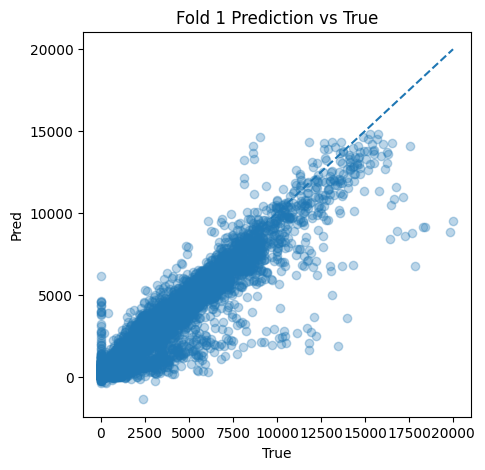

store_nbr
44    204.035142
45    190.643881
47    177.350095
3     169.475498
49    156.431388
46    134.986735
48    126.699593
51    106.757571
7     104.482840
9      94.327032
Name: abs_error, dtype: float64
family
GROCERY I        544.874911
BEVERAGES        508.014489
PRODUCE          399.531066
CLEANING         198.342113
DAIRY            121.248602
BREAD/BAKERY      76.992751
POULTRY           76.902418
PERSONAL CARE     69.539639
MEATS             69.523418
DELI              55.518972
Name: abs_error, dtype: float64


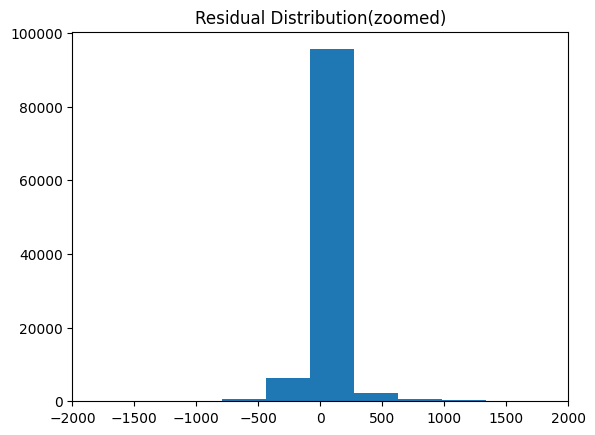

              date store_nbr     family      sales  is_holiday  dayofweek  \
1952739 2016-01-04        44    PRODUCE  13465.525       False          0   
1950957 2016-01-03        44    PRODUCE  17824.008       False          6   
1950963 2016-01-03        45  BEVERAGES  19799.000       False          6   
1950972 2016-01-03        45  GROCERY I  19988.629       False          6   
1952754 2016-01-04        45  GROCERY I  13965.000       False          0   
1952904 2016-01-04        49    PRODUCE  11795.438       False          0   
1951386 2016-01-04         3    PRODUCE  11825.318       False          0   
1952745 2016-01-04        45  BEVERAGES  12236.000       False          0   
1950930 2016-01-03        44  BEVERAGES  18421.000       False          6   
1952712 2016-01-04        44  BEVERAGES  11911.000       False          0   

         month  is_weekend   sin_dow  cos_dow  ...  onpromotion_lag7  \
1952739      1           0  0.000000  1.00000  ...               0.0   
1950957 

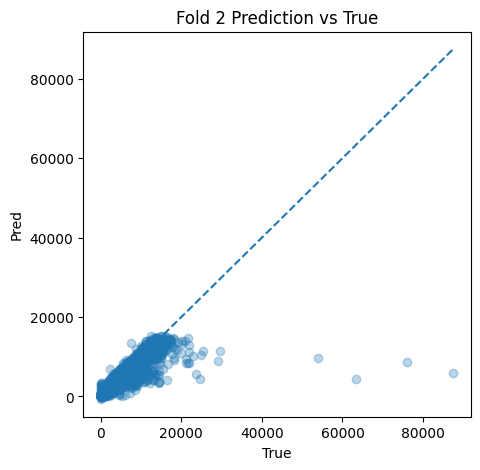

store_nbr
45    200.598677
44    199.869325
20    144.565255
46    135.816177
3     130.094285
47    128.108404
48    121.634053
49    114.425506
2     114.353469
51    104.230162
Name: abs_error, dtype: float64
family
GROCERY I        799.610039
BEVERAGES        485.125165
PRODUCE          214.494174
CLEANING         186.537449
DAIRY             99.989725
PERSONAL CARE     88.650269
POULTRY           67.676736
HOME CARE         65.567469
BREAD/BAKERY      63.674401
MEATS             60.442975
Name: abs_error, dtype: float64


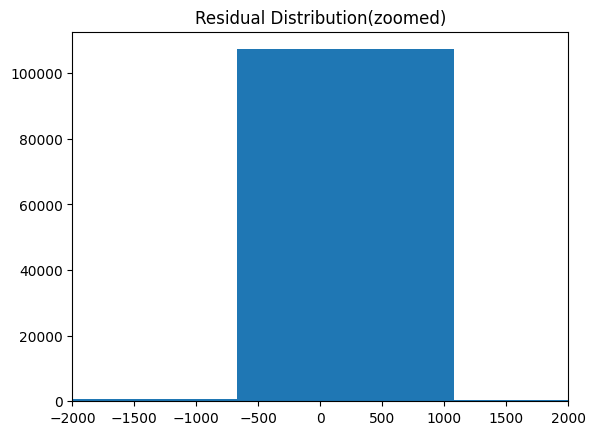

              date store_nbr     family      sales  is_holiday  dayofweek  \
2144385 2016-04-21        20  GROCERY I  87438.516        True          3   
2139864 2016-04-18        45  GROCERY I  76090.000        True          0   
2152701 2016-04-26         2  GROCERY I  63434.000        True          1   
2145210 2016-04-21        45  GROCERY I  53874.000        True          3   
2144376 2016-04-21        20  BEVERAGES  24612.000        True          3   
2139831 2016-04-18        44  GROCERY I  29193.000        True          0   
2138049 2016-04-17        44  GROCERY I  29670.000        True          6   
2143791 2016-04-21         2  GROCERY I  23687.000        True          3   
2141613 2016-04-19        44  GROCERY I  24861.000        True          1   
2138040 2016-04-17        44  BEVERAGES  25413.000        True          6   

         month  is_weekend   sin_dow   cos_dow  ...  onpromotion_lag7  \
2144385      4           0  0.433884 -0.900969  ...              29.0   
213986

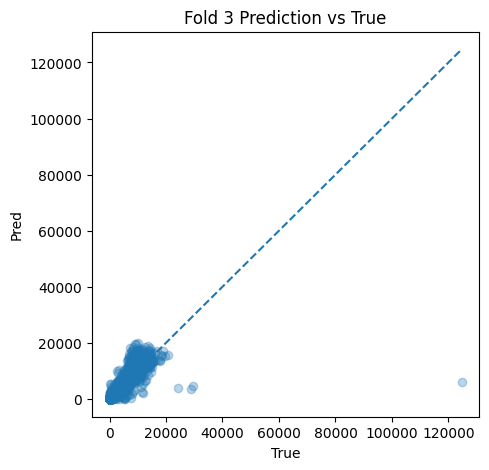

store_nbr
45    224.746250
44    209.609945
20    171.424148
47    166.450704
3     157.129866
49    153.950712
53    145.936244
2     141.890288
46    131.211604
48    120.218141
Name: abs_error, dtype: float64
family
GROCERY I        893.434198
BEVERAGES        413.339445
PRODUCE          246.012115
CLEANING         179.245040
DAIRY            110.746684
PERSONAL CARE     71.806961
BREAD/BAKERY      70.814049
MEATS             65.515509
POULTRY           64.433800
HOME CARE         46.754170
Name: abs_error, dtype: float64


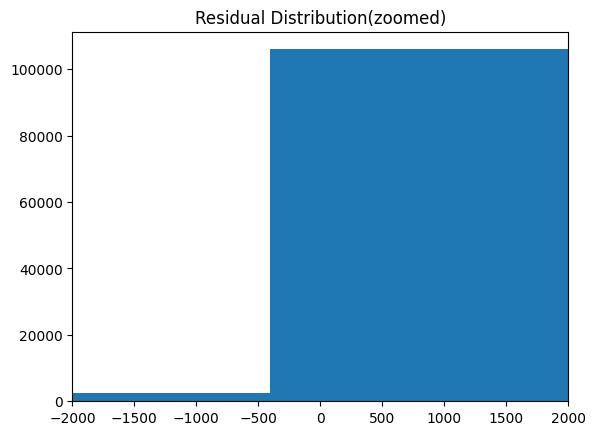

              date store_nbr     family       sales  is_holiday  dayofweek  \
2163393 2016-05-02         2  GROCERY I  124717.000        True          0   
2245959 2016-06-17        20  GROCERY I   28998.662       False          4   
2263779 2016-06-27        20  GROCERY I   29490.850       False          0   
2181807 2016-05-12        20  GROCERY I   24264.850        True          3   
2174118 2016-05-08         3  GROCERY I    7409.000        True          6   
2168376 2016-05-04        45  GROCERY I    9000.000        True          2   
2264571 2016-06-27        44  GROCERY I    8240.000       False          0   
2177286 2016-05-09        45  GROCERY I    9511.000        True          0   
2261436 2016-06-26         3  GROCERY I   10046.000       False          6   
2264604 2016-06-27        45  GROCERY I    8295.000       False          0   

         month  is_weekend   sin_dow   cos_dow  ...  onpromotion_lag7  \
2163393      5           0  0.000000  1.000000  ...              31.

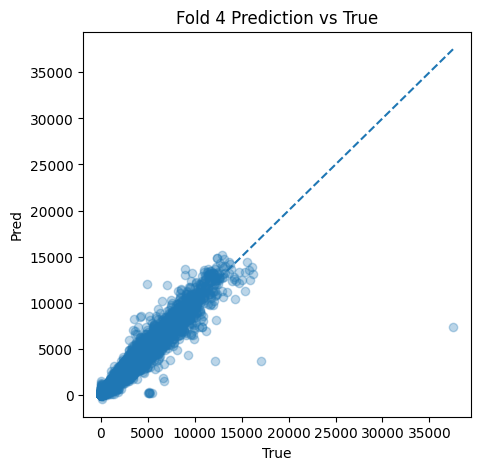

store_nbr
44    123.560591
20    115.018419
45    113.444975
47     99.754531
3      95.139467
46     90.985474
49     90.069501
48     87.197911
11     81.763357
39     80.326910
Name: abs_error, dtype: float64
family
GROCERY I        475.316572
BEVERAGES        318.701250
PRODUCE          204.076696
CLEANING         144.402324
DAIRY             91.733465
MEATS             66.386753
BREAD/BAKERY      57.494906
POULTRY           55.845083
PERSONAL CARE     51.271144
HOME CARE         42.690117
Name: abs_error, dtype: float64


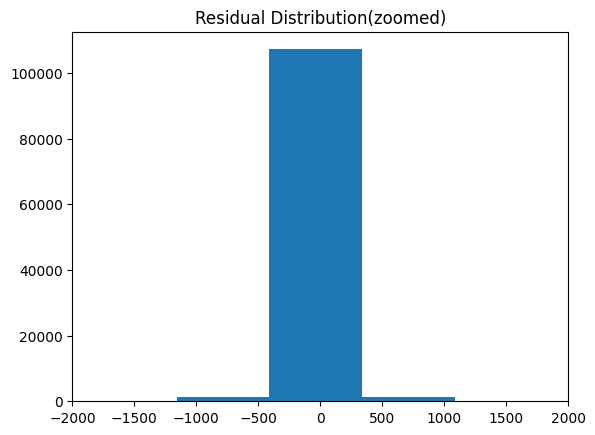

              date store_nbr     family       sales  is_holiday  dayofweek  \
2276253 2016-07-04        20  GROCERY I  37514.9260       False          0   
2306547 2016-07-21        20  GROCERY I  17073.4300       False          3   
2276244 2016-07-04        20  BEVERAGES  12153.0000       False          0   
2278035 2016-07-05        20  GROCERY I   4889.3980       False          1   
2355300 2016-08-17        39      MEATS   5474.6290       False          2   
2317164 2016-07-27        18  BEVERAGES   6748.0000       False          2   
2319660 2016-07-28        39      MEATS   5249.7603       False          3   
2333916 2016-08-05        39      MEATS   5177.5710        True          4   
2352879 2016-08-16        20  GROCERY I   9255.0230       False          1   
2292930 2016-07-13        39      MEATS   5136.8594       False          2   

         month  is_weekend   sin_dow   cos_dow  ...  onpromotion_lag7  \
2276253      7           0  0.000000  1.000000  ...              28.

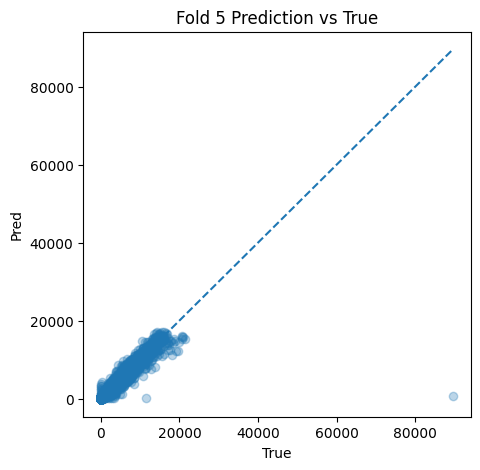

store_nbr
44    153.213332
45    121.399034
39    118.283602
49    110.503484
47    109.133888
46    103.726300
3     103.101370
48     97.275885
20     92.542006
11     91.394439
Name: abs_error, dtype: float64
family
GROCERY I        481.960191
BEVERAGES        340.652751
PRODUCE          214.482161
CLEANING         163.116015
MEATS             90.683809
DAIRY             89.894466
BREAD/BAKERY      57.987797
POULTRY           56.515994
PERSONAL CARE     52.590592
EGGS              49.437832
Name: abs_error, dtype: float64


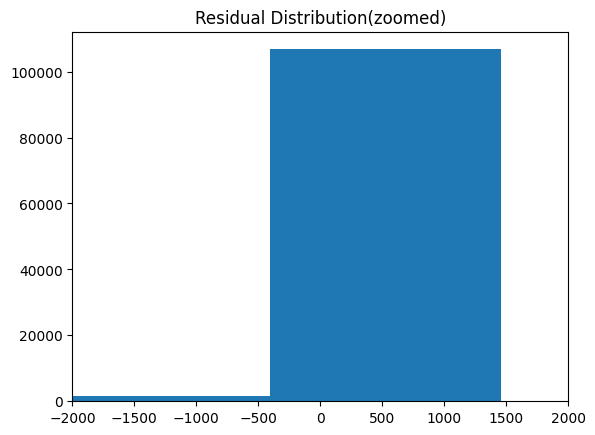

              date store_nbr     family      sales  is_holiday  dayofweek  \
2446182 2016-10-07        39      MEATS  89576.360        True          4   
2455983 2016-10-13        12      MEATS  11609.557       False          3   
2435676 2016-10-01        45  GROCERY I  19588.000       False          5   
2435709 2016-10-01        46  GROCERY I  19223.000       False          5   
2435775 2016-10-01        48  GROCERY I  18206.000       False          5   
2437425 2016-10-02        44  GROCERY I  21540.000       False          6   
2434488 2016-10-01         9  GROCERY I  13856.361       False          5   
2437416 2016-10-02        44  BEVERAGES  20692.000       False          6   
2437491 2016-10-02        46  GROCERY I  20011.000       False          6   
2434554 2016-10-01        11  GROCERY I  12797.128       False          5   

         month  is_weekend   sin_dow   cos_dow  ...  onpromotion_lag7  \
2446182     10           0 -0.433884 -0.900969  ...               0.0   
245598

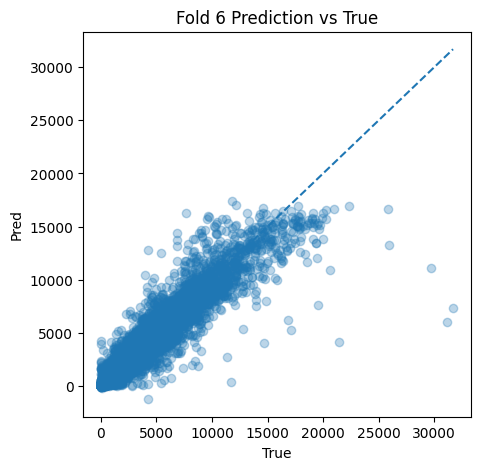

store_nbr
45    229.157528
44    226.453290
46    204.556409
47    192.881262
48    166.708484
49    160.188259
3     159.799463
11    124.381120
24    120.401292
50    118.486901
Name: abs_error, dtype: float64
family
GROCERY I        929.269003
BEVERAGES        541.088820
PRODUCE          297.786813
CLEANING         217.768875
FROZEN FOODS     160.952509
DAIRY            137.600163
POULTRY           82.144061
MEATS             74.870158
PERSONAL CARE     73.352873
BREAD/BAKERY      71.670876
Name: abs_error, dtype: float64


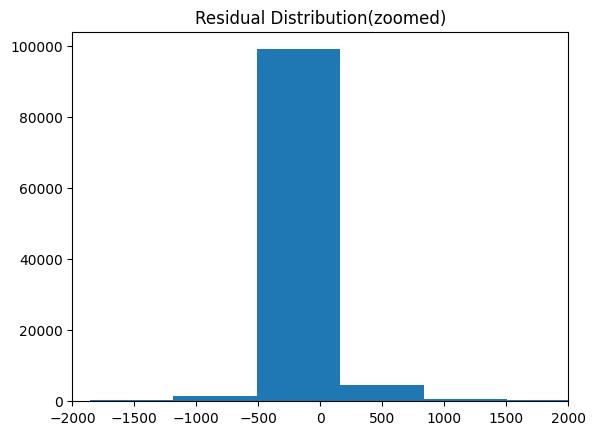

              date store_nbr        family      sales  is_holiday  dayofweek  \
2563650 2016-12-12        35     GROCERY I  31125.521       False          0   
2550813 2016-12-05        24     GROCERY I  31689.000        True          0   
2578236 2016-12-20        45     GROCERY I  29666.000       False          1   
2520519 2016-11-18        24     GROCERY I  21462.000       False          4   
2576454 2016-12-19        45     GROCERY I  25938.000       False          0   
2544411 2016-12-01        46     GROCERY I  19540.000       False          3   
2570943 2016-12-16        40     GROCERY I  17114.078       False          4   
2551274 2016-12-05        38  FROZEN FOODS  11706.615        True          0   
2577609 2016-12-20        26     GROCERY I  14665.000       False          1   
2543190 2016-12-01         9     GROCERY I  16818.836       False          3   

         month  is_weekend   sin_dow   cos_dow  ...  onpromotion_lag7  \
2563650     12           0  0.000000  1.000000

In [3]:
params = {
    "objective": "regression",
    "n_estimators": 500,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "random_state": 42,
    "n_jobs": -1
}
fold_scores = []
oof_pred = np.zeros(len(df_feature))
oof_mask = np.zeros(len(df_feature), dtype=bool)
folds = [
    ("2013-01-01", "2015-12-31", "2016-01-01", "2016-02-29"),
    ("2013-01-01", "2016-02-29", "2016-03-01", "2016-04-30"),
    ("2013-01-01", "2016-04-30", "2016-05-01", "2016-06-30"),
    ("2013-01-01", "2016-06-30", "2016-07-01", "2016-08-31"),
    ("2013-01-01", "2016-08-31", "2016-09-01", "2016-10-31"),
    ("2013-01-01", "2016-10-31", "2016-11-01", "2016-12-31"),
]
for fold_id,(train_start,train_end,valid_start,valid_end) in enumerate(folds, start=1):
    print(f"Fold {fold_id}")
    print(f"Train: {train_start} -> {train_end}")
    print(f"Valid: {valid_start} -> {valid_end}")
    train_mask=(df_feature["date"]>=train_start)&(df_feature["date"]<=train_end)
    valid_mask=(df_feature["date"]>=valid_start)&(df_feature["date"]<=valid_end)
    train_df = df_feature.loc[train_mask].copy()
    valid_df = df_feature.loc[valid_mask].copy()

    X_train=train_df.drop(columns=["date","sales"])
    y_train=train_df["sales"]
    X_valid=valid_df.drop(columns=["date","sales"])
    y_valid=valid_df["sales"]
    
    features=X_train.columns.tolist()
    model = LGBMRegressor(**params)
    model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse"
)
    pred_valid = model.predict(X_valid)
    rmse = np.sqrt(mean_squared_error(y_valid, pred_valid))

    print(f"Fold {fold_id} RMSE: {rmse:.4f}")

    fold_scores.append(rmse)

    oof_pred[valid_df.index] = pred_valid
    oof_mask[valid_df.index] = True

    print("=" * 60)
    print("Fold RMSEs:", [round(s, 4) for s in fold_scores])
    print("Mean RMSE:", round(np.mean(fold_scores), 4))
    importance_df = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print(importance_df.head(20))

    valid_df["pred"] = pred_valid
    valid_df["residual"] = valid_df["sales"] - valid_df["pred"]
    valid_df["abs_error"] = valid_df["residual"].abs()
    

    plt.figure(figsize=(5,5))
    plt.scatter(y_valid, pred_valid, alpha=0.3)
    plt.xlabel("True")
    plt.ylabel("Pred")
    plt.title(f"Fold {fold_id} Prediction vs True")
    plt.plot([y_valid.min(), y_valid.max()],
             [y_valid.min(), y_valid.max()],
             linestyle="--")
    plt.show()
    
    store_error = valid_df.groupby("store_nbr")["abs_error"].mean().sort_values(ascending=False)
    print(store_error.head(10))

    
    family_error = (
    valid_df
    .groupby("family")["abs_error"]
    .mean()
    .sort_values(ascending=False)
    )

    print(family_error.head(10))
    
    plt.hist(valid_df["residual"], bins=50)
    plt.xlim(-2000, 2000) 
    plt.title("Residual Distribution(zoomed)")
    plt.show()
    print(valid_df.sort_values("abs_error", ascending=False).head(10))

### 📊 Feature Importance Analysis

基于 LightGBM 模型的特征重要性（feature importance），可以将影响销量预测的因素分为三个层级：

---

#### 🟢 1. 核心驱动因素（Primary Drivers）

* `store_nbr`
* `sales_lag1`, `sales_lag7`
* `transactions_diff_1`, `transactions_lag1`, `transactions_lag7`

这些特征构成了模型的主要预测依据：

* **store_nbr**（以 categorical 形式引入）刻画了不同门店之间的结构差异，是最重要的分割维度；
* **sales_lag 系列特征**反映销量的时间惯性（temporal dependency），是时间序列预测的核心；
* **transactions 系列特征**作为客流量的代理变量，反映了需求强度，对销量具有直接影响。

👉 该层级体现了模型的核心结构：

> 销量 ≈ 历史销量（惯性） + 当前需求（transactions） + 门店差异（store）

---

#### 🔵 2. 结构与周期因素（Structural & Seasonal Factors）

* `dayofweek`, `month`, `sin_dow`
* `sales_diff_1`, `sales_rolling_mean7`
* `transactions_rolling_mean7`
* `family`

这一类特征主要用于对基础预测进行结构性修正：

* 时间周期特征（如星期、月份）捕捉周期性模式；
* rolling / diff 特征反映短期趋势变化；
* **family（商品类别）**提供商品层面的结构信息，在模型中表现为**中等重要性变量**。

👉 说明：

> 商品类别会影响销量模式，但不是短期波动的主要驱动因素。

---

#### 🟡 3. 辅助扰动因素（Secondary / Perturbation Signals）

* `onpromotion_lag1`, `onpromotion_lag7`
* `onpromotion_diff_1`, `onpromotion_rolling_mean7`
* `is_holiday`
* `store_baseline`, `family_baseline`, `family_ratio_hist`

该层级特征对模型有一定贡献，但整体影响较弱：

* **promotion 与 holiday** 对销量有影响，但在当前数据中并非主要驱动；
* baseline / ratio 特征提供长期结构信息，但被更强的 lag 与 transactions 特征部分替代。

---

### 🧠 Key Insights

* 模型主要依赖**时间序列惯性（lag）与需求信号（transactions）**进行预测；
* **store_nbr** 作为 categorical 特征后显著提升重要性，说明不同门店之间存在明显异质性；
* **family（商品类别）**具有中等重要性，提供结构性约束，但不主导短期预测；
* **promotion 与 holiday** 在当前特征体系下影响较弱，可能已被其他特征间接吸收；
* 整体模型呈现出“时间驱动 + 结构修正”的建模模式。

---

### 🧩 Modeling Perspective

该模型可以理解为一种**隐式分层建模（implicit hierarchical modeling）**：

```
Store-level heterogeneity
    ↓
Product family structure
    ↓
Temporal dynamics (dominant)
```

即：模型首先区分不同门店，再在商品类别结构下，主要依赖时间动态进行预测。


### 📉 模型误差分析与行为总结

#### 🔹 整体表现

模型在**常规销量区间内拟合良好**，能够有效捕捉大多数样本的变化趋势。但在**极端高销量场景**下存在明显的低估现象，体现出典型的**长尾分布预测困难问题**。

---

#### 🔹 长尾分布特征

极端销量样本主要集中在食品类，尤其是 **GROCERY I**，且在不同门店中均有出现。这表明该现象**并非由单一门店驱动**，而是来源于**商品类别层面的需求波动**。

模型在常规区间表现稳定，但由于缺乏能够捕捉“需求触发机制”的特征（如促销强度、节前囤货行为等），在高销量场景下存在**系统性低估**。

---

#### 🔹 误差结构拆解

模型误差主要来源于两类：

1. **长尾误差（低频高影响）**

   * 主要集中在 **GROCERY I、BEVERAGES** 等类别
   * 由突发性需求增长引起
   * 样本数量较少，但对整体 RMSE 贡献较大

2. **系统性误差（高频中等影响）**

   * 出现在 **PRODUCE、CLEANING** 等类别中
   * 表现为持续性的预测偏差
   * 说明模型对这些类别的模式建模仍不充分

此外，部分门店（如 **store 45、44、20**）在多个时间窗口中均表现出较高误差，说明其销售行为更复杂或波动更大。

---

#### 🔹 对数变换尝试

曾尝试对目标变量进行对数变换（log transformation）以缓解长尾分布问题。结果显示，虽然残差分布在变换后更接近对称形态，但在还原至原始销量空间后，模型的 RMSE 反而上升，且预测整体存在偏高现象。

因此，在本项目中最终仍采用**原始销量作为建模目标**，以保证评估指标与业务目标的一致性。

---

#### 🔹 残差周期性分析

尝试按星期维度分析残差分布，但在不同 rolling 时间窗口下结果不一致，未观察到稳定的周期性偏差。因此，该分析未纳入最终结论。

---

### 🧠 关键结论

* 模型在**常规销量区间表现稳定**，但在**极端需求场景下存在系统性低估**
* 误差来源同时包含**长尾冲击**与**类别建模不足**两类机制
* 当前模型以“时间动态”为主导，对“需求触发机制”的刻画仍然不足
* 后续优化方向应更多关注**触发型特征构建**，而非单纯模型复杂度提升


## Limitations & Future Work

- 模型无法捕捉突发需求（如节前囤货）
- 缺乏促销强度特征
- 长尾分布导致高销量预测偏差

未来可以：
- 引入事件/节日特征
- 使用分段建模（low/high sales）